# Image Chart

An image chart places a picture in the coordinates of the data: its pixels stretch over an `extent`, the rectangle `(xmin, xmax, ymin, ymax)` it covers on the axes. On its own it is a picture with axes; its use is underneath another chart that shares those coordinates, so the marks have something to sit on: epicentres on the relief of a region, sensors on a floor plan, detections on a microscope image. This guide shows how to create image charts with the [datachart.charts.ImageChart](../../../references/charts/imagechart/#datachart.charts.ImageChart) function and how to compose them with other charts, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-image-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
import numpy as np

from datachart.charts import ImageChart, ScatterChart
from datachart.utils import Panel

## Basics

The examples in this guide share one dataset: the relief of the Aegean and Anatolia, between 34 and 42 degrees north and 19 and 45 degrees east, sampled every quarter degree from [NOAA's ETOPO](https://www.ncei.noaa.gov/products/etopo-global-relief-model) global model (public domain), and the 54 earthquakes of magnitude 5 and above that struck the region in 2023, from the [USGS earthquake catalogue](https://earthquake.usgs.gov/fdsnws/event/1/) (public domain). The hidden cell below holds both. `RELIEF` has `lat` and `lon` axes and a `z` row per latitude, in metres above sea level; `QUAKES` is one tuple per earthquake: the hours since the start of 2023, the latitude, the longitude, the depth in kilometres, and the magnitude.

In [2]:
# NOAA ETOPO global relief (public domain), sampled every quarter degree (metres)
RELIEF = {
    "lat": [34, 34.25, 34.5, 34.75, 35, 35.25, 35.5, 35.75, 36, 36.25, 36.5, 36.75, 37, 37.25, 37.5, 37.75, 38, 38.25, 38.5, 38.75, 39, 39.25, 39.5, 39.75, 40, 40.25, 40.5, 40.75, 41, 41.25, 41.5, 41.75, 42],
    "lon": [19, 19.25, 19.5, 19.75, 20, 20.25, 20.5, 20.75, 21, 21.25, 21.5, 21.75, 22, 22.25, 22.5, 22.75, 23, 23.25, 23.5, 23.75, 24, 24.25, 24.5, 24.75, 25, 25.25, 25.5, 25.75, 26, 26.25, 26.5, 26.75, 27, 27.25, 27.5, 27.75, 28, 28.25, 28.5, 28.75, 29, 29.25, 29.5, 29.75, 30, 30.25, 30.5, 30.75, 31, 31.25, 31.5, 31.75, 32, 32.25, 32.5, 32.75, 33, 33.25, 33.5, 33.75, 34, 34.25, 34.5, 34.75, 35, 35.25, 35.5, 35.75, 36, 36.25, 36.5, 36.75, 37, 37.25, 37.5, 37.75, 38, 38.25, 38.5, 38.75, 39, 39.25, 39.5, 39.75, 40, 40.25, 40.5, 40.75, 41, 41.25, 41.5, 41.75, 42, 42.25, 42.5, 42.75, 43, 43.25, 43.5, 43.75, 44, 44.25, 44.5, 44.75, 45],
    "z": [
        (-3610, -3900, -3961, -3988, -3306, -2917, -2683, -2567, -2474, -2445, -2406, -2299, -2127, -2139, -2350, -2338, -2440, -2561, -2172, -1894, -1728, -1851, -2476, -2925, -2662, -2644, -3004, -2738, -2873, -3291, -3270, -2757, -2682, -2615, -2564, -2484, -2842, -2804, -2630, -2711, -3039, -2889, -3001, -2835, -3023, -2866, -2764, -2746, -2590, -2556, -2616, -2577, -2590, -2709, -2689, -2264, -2082, -2453, -2252, -2238, -2180, -2103, -2029, -1918, -1818, -1537, -1040, 1261, 1303, 1494, 2036, 1270, 1011, 978, 1035, 901, 695, 596, 605, 690, 693, 639, 625, 552, 493, 450, 421, 420, 392, 371, 382, 356, 290, 200, 122, 145, 88, 44, 73, 64, 54, 49, 53, 51, 59),
        (-3833, -3981, -3770, -3368, -3143, -2819, -2655, -2532, -2577, -2476, -2258, -2457, -2275, -2366, -2395, -2664, -2678, -2603, -2586, -2030, -1949, -1909, -2552, -2683, -3519, -3345, -3970, -3337, -2790, -2331, -2901, -3071, -2654, -2670, -2651, -2493, -2521, -2461, -2584, -2699, -2875, -2761, -2935, -3194, -2805, -2662, -2610, -2596, -2481, -2534, -2472, -2489, -2402, -2504, -2575, -2702, -2151, -2038, -1974, -1833, -2060, -2098, -2056, -1981, -1875, -1750, -1799, 355, 1358, 1697, 1311, 1175, 955, 750, 736, 1038, 640, 479, 460, 501, 574, 572, 556, 490, 445, 376, 359, 317, 230, 278, 290, 256, 203, 168, 172, 172, 68, 110, 102, 93, 62, 64, 64, 67, 90),
        (-3861, -3763, -3359, -3118, -2968, -2801, -2704, -2697, -2603, -2606, -2158, -2410, -2234, -2897, -2817, -2807, -2771, -2749, -2693, -2507, -2666, -2879, -1880, -2235, -2068, -1564, -1391, -1192, -3280, -3730, -3510, -1929, -2097, -2242, -2635, -2583, -2512, -2584, -2473, -2547, -2781, -2643, -2698, -2721, -2611, -2436, -2452, -2444, -2422, -2407, -2377, -2372, -2342, -2790, -2273, -1047, -1671, -844, -766, -802, -942, -1535, -1413, -1574, -1882, -1823, -1730, -69, 116, 1500, 522, 707, 814, 703, 581, 510, 493, 380, 393, 403, 389, 419, 402, 406, 373, 327, 270, 257, 197, 211, 197, 160, 189, 223, 238, 177, 71, 131, 119, 78, 71, 85, 93, 131, 136),
        (-3760, -3658, -3314, -3053, -2969, -2852, -2832, -2658, -2619, -2427, -2498, -2898, -3182, -3083, -2938, -2865, -2906, -2797, -2838, -2718, -570, -993, -2671, -2237, -2441, -1035, -710, -962, -1969, -1707, -2922, -3096, -2311, -2163, -2706, -2725, -2597, -2600, -2609, -2572, -2453, -2453, -2442, -2406, -2396, -2416, -2400, -2390, -2441, -2348, -2219, -1935, -2244, -1580, 96, 513, 282, 233, -220, -1215, -1891, -1629, -885, -1421, -1609, -1575, -1762, -486, 48, 383, 629, 519, 592, 963, 889, 762, 979, 757, 668, 508, 457, 357, 309, 298, 283, 242, 237, 179, 203, 170, 300, 329, 319, 284, 224, 168, 84, 140, 143, 111, 132, 185, 174, 185, 309),
        (-3819, -3470, -3250, -3053, -2988, -2953, -2930, -2751, -2552, -2777, -3277, -3230, -3234, -3169, -3125, -3149, -3252, -3143, -3605, -799, -447, -1370, -1255, 27, 229, 430, 123, -25, -206, -831, -1958, -2366, -3158, -2558, -782, -2113, -1975, -3186, -2714, -2892, -2798, -2856, -2550, -2434, -2422, -2428, -2377, -2369, -2346, -2272, -2270, -2204, -2171, -520, 383, 822, 716, 462, 231, 51, 90, -899, -952, -1203, -1284, -1526, -1155, -1289, 361, 815, 446, 435, 435, 570, 749, 871, 921, 776, 731, 598, 412, 318, 282, 263, 259, 242, 187, 207, 206, 186, 207, 287, 317, 251, 236, 176, 104, 155, 136, 319, 158, 175, 200, 349, 465),
        (-3716, -3443, -3169, -3126, -2980, -2998, -3006, -3051, -3002, -3354, -3489, -3342, -3355, -3562, -3599, -3790, -3571, -3273, -651, 327, 1040, 886, 488, 1661, 265, 319, 790, -8, -70, 38, -561, -1183, -1307, -933, -1230, -1541, -1194, -1743, -3514, -3806, -3187, -3225, -2732, -2378, -2423, -2214, -2256, -2342, -2242, -2369, -2411, -2416, -2434, -1407, -574, -266, 71, 208, 167, 53, -275, -715, -888, -931, -937, -969, -1148, -731, 227, 1257, 202, 354, 506, 517, 459, 548, 493, 496, 461, 429, 508, 715, 505, 376, 307, 199, 220, 229, 197, 224, 270, 296, 241, 239, 237, 181, 140, 210, 154, 183, 193, 216, 330, 486, 483),
        (-3696, -3413, -3271, -3131, -3038, -2897, -3067, -2963, -2789, -3232, -3596, -3673, -3648, -3673, -4107, -4379, -2703, -3038, -1241, 202, 19, -134, -404, -273, -362, -248, -269, -655, -1077, -1280, -816, -2017, -265, -258, -1323, -441, -1949, -2535, -3596, -3539, -2889, -2635, -1945, -1609, -2044, -1299, -1492, -1794, -2330, -2493, -2680, -2508, -2354, -2095, -1786, -748, -655, -708, -773, -495, -193, 75, -617, -1007, -1104, -1199, -1446, -31, 186, 177, 445, 405, 378, 306, 321, 366, 414, 392, 338, 324, 371, 488, 594, 403, 207, 276, 236, 237, 267, 243, 289, 213, 226, 216, 203, 204, 206, 148, 198, 199, 286, 282, 483, 863, 665),
        (-3593, -3493, -3210, -3090, -3122, -3172, -3149, -2917, -3008, -3837, -3975, -4191, -3721, -3862, -4643, -1679, -2097, -520, -393, -369, -620, -985, -1051, -959, -1138, -925, -962, -1080, -1902, -2093, -1142, -1387, -2473, -808, -992, -855, -1263, -3328, -4112, -3820, -3984, -3027, -2415, -2909, -2200, -2375, -1658, -2362, -2470, -2499, -2526, -2452, -2468, -2422, -2357, -1712, -1208, -1014, -1074, -1034, -888, -711, -319, -467, -1119, -1272, -1362, -578, 396, 1014, 659, 421, 277, 308, 352, 344, 364, 351, 361, 275, 364, 332, 291, 218, 349, 352, 270, 247, 290, 280, 261, 256, 238, 251, 222, 189, 213, 185, 244, 330, 333, 311, 741, 619, 1013),
        (-3655, -3307, -3171, -3094, -3222, -3157, -2968, -2899, -3206, -3877, -3571, -4006, -3678, -4628, -3188, -981, -902, -59, -1327, -1145, -1272, -1510, -927, -1167, -1555, -1864, -1542, -1280, -788, -779, -273, -1222, -2041, -1165, -824, 17, -757, -2564, -4424, -4423, -3941, -2584, -2121, -2734, -3051, -2992, -2535, -2666, -2649, -2602, -2600, -2558, -2329, -1187, -967, -28, -592, -731, -618, -706, -921, -926, -823, -798, -892, -993, -442, -257, 521, 656, 447, 308, 310, 524, 329, 334, 366, 307, 348, 255, 259, 259, 317, 324, 329, 319, 296, 263, 284, 309, 305, 300, 309, 266, 219, 224, 307, 240, 233, 324, 377, 645, 519, 579, 546),
        (-3602, -3387, -3166, -3195, -3184, -3117, -2798, -2897, -3897, -4127, -3988, -3431, -3222, -2209, -2159, -1014, 260, -1193, -618, -862, -962, -1042, -940, -1129, -468, -457, -401, -294, -338, -660, -665, -481, -934, -640, -567, -160, 297, -1113, -3350, -3095, -1700, -301, 992, 535, 11, -63, -131, -2605, -2467, -2296, -2488, -2423, -1842, -169, 422, 1354, 869, 566, 731, 324, -8, -472, -479, -263, -127, -197, -169, -153, 650, 118, 93, 381, 434, 456, 400, 404, 366, 327, 386, 335, 283, 373, 433, 484, 549, 468, 397, 282, 346, 430, 456, 405, 378, 305, 289, 356, 387, 239, 304, 369, 420, 899, 1148, 560, 552),
        (-3457, -3286, -3270, -3283, -3141, -2943, -2837, -2874, -4193, -4329, -4440, -2513, -2305, -2188, -30, -1354, -16, -914, -565, -679, -677, -946, -510, -527, -491, -153, -314, -614, -423, -315, -453, -555, -456, -342, -482, -783, -425, -267, -1557, -1939, -748, 526, 2005, 1818, 1634, 347, 131, -1720, -1335, -1558, -1831, -1383, -497, 419, 1855, 1897, 1476, 1011, 139, 1067, 770, -86, -220, -135, -65, -27, -58, -92, -2, 1209, 121, 597, 514, 444, 531, 535, 489, 331, 512, 365, 328, 343, 358, 423, 466, 412, 361, 301, 357, 425, 418, 453, 471, 517, 379, 245, 293, 307, 353, 346, 509, 920, 1594, 1100, 2494),
        (-3483, -3363, -3389, -3229, -3166, -2896, -2840, -3355, -3742, -3395, -3099, 1, -138, -842, 98, -477, 114, -641, -426, -583, -648, -234, 22, -293, -272, -14, -212, -457, -720, -132, -546, -265, -66, -641, 103, -22, -12, 375, -183, 25, 94, 961, 1454, 1842, 1124, 1733, 1123, -804, -380, -364, 2, 255, 888, 1022, 1941, 1098, 1817, 420, 1600, 1485, 1386, 1134, 64, -16, 1, 5, 7, -5, -60, 296, 405, 748, 390, 601, 605, 507, 381, 478, 521, 395, 351, 447, 425, 435, 367, 389, 394, 360, 353, 336, 346, 358, 382, 368, 384, 308, 662, 574, 454, 565, 1140, 924, 810, 1699, 2904),
        (-3413, -3479, -3460, -3782, -3706, -3238, -2912, -2680, -2165, -1854, -731, 282, -47, 1080, 142, 466, 133, -493, -863, -795, -920, -588, -428, -87, -56, -1, 464, -227, -368, -260, -33, -386, 239, 2, 186, 32, -130, 20, 95, 955, 725, 1009, 1146, 1606, 1639, 1015, 763, 124, 42, 95, 1342, 971, 2488, 1742, 1386, 1308, 1383, 1293, 1549, 1920, 2131, 1544, 1103, 195, 65, 25, 87, 25, 161, 758, 1736, 447, 839, 931, 745, 593, 399, 628, 496, 501, 390, 623, 539, 461, 450, 415, 444, 428, 433, 419, 394, 432, 448, 471, 377, 662, 722, 1380, 1395, 1145, 1761, 1158, 1369, 2623, 1610),
        (-3330, -3284, -3480, -3486, -3420, -2867, -3236, -2551, 7, -1287, -749, 358, 89, 620, 778, 938, -697, -198, -253, -549, -765, -466, -113, -261, -90, -104, -92, -245, -181, -426, -369, -79, -88, -85, -5, 48, 656, 482, 1206, 725, 980, 1040, 941, 1222, 1601, 926, 786, 451, 887, 529, 1948, 1233, 1189, 1300, 1393, 1263, 1032, 1009, 1114, 1323, 1646, 2796, 2317, 1104, 412, 161, 202, 48, 32, 152, 880, 684, 618, 898, 703, 585, 627, 603, 685, 747, 558, 693, 620, 596, 513, 508, 515, 578, 844, 922, 1007, 796, 633, 411, 572, 755, 1525, 1457, 1729, 1927, 1749, 1523, 1634, 2614, 1925),
        (-3291, -3236, -3340, -3463, -3433, -3973, -4052, -2903, -1010, -909, -502, 821, 299, 888, 676, -31, 5, 416, 7, -140, -181, -357, -273, -210, -136, -108, -170, -432, -167, -412, -4, -88, -41, 128, -2, 769, 521, 646, 743, 626, 900, 1477, 1060, 1225, 1192, 1423, 949, 408, 1300, 1230, 1147, 1227, 1530, 1368, 1084, 1027, 1003, 1098, 1005, 998, 1031, 1460, 1436, 1357, 1614, 870, 420, 307, 266, 265, 576, 986, 603, 848, 920, 906, 555, 573, 530, 675, 646, 702, 876, 1007, 962, 975, 1036, 1042, 1110, 986, 951, 867, 1038, 749, 1404, 1689, 1796, 2293, 1791, 1863, 3108, 1889, 2568, 2272, 1488),
        (-3253, -3219, -3276, -3426, -3348, -2341, -1813, 436, -299, -66, 198, 764, 643, 809, 1104, 220, 826, -136, 158, -161, 189, -121, -183, -251, -21, -391, -830, -735, -691, -1300, -714, 372, 161, -9, 11, 117, 341, 806, 1281, 771, 925, 743, 1118, 862, 1488, 859, 1329, 2323, 1429, 1672, 1122, 1173, 2034, 1466, 1016, 1001, 1003, 1027, 1038, 1800, 1038, 1038, 1063, 1672, 1425, 2866, 1540, 1334, 1000, 1580, 1667, 833, 1062, 1300, 1187, 853, 693, 670, 583, 620, 572, 735, 1001, 1302, 977, 731, 665, 660, 619, 802, 822, 531, 970, 1430, 2405, 1598, 2022, 2538, 3169, 2518, 2578, 2486, 2715, 1907, 1476),
        (-3228, -3297, -3352, -3445, -3781, -850, -576, -134, -118, -16, 288, 365, 1051, 1485, 526, 13, 910, 447, 71, 191, 44, 207, 428, 10, -452, -443, -563, -355, -419, -917, -431, -315, -185, 199, 119, 683, 718, 1002, 827, 646, 160, 1244, 816, 1161, 970, 1590, 1614, 1392, 1365, 1342, 1534, 1623, 1541, 1502, 1143, 1002, 1243, 1029, 1073, 1054, 1122, 1290, 2218, 1318, 1750, 2677, 1354, 1519, 1460, 1542, 1336, 1544, 1375, 1701, 1857, 1629, 1358, 1621, 1109, 1778, 561, 957, 832, 831, 794, 595, 655, 657, 677, 774, 640, 605, 1335, 1479, 1758, 2297, 2167, 2744, 2285, 2741, 2117, 2792, 2368, 1920, 1512),
        (-3553, -3568, -3649, -2550, -2884, -2522, 650, -191, -89, -43, -90, 76, 223, -632, -780, -297, 199, 289, 424, 203, 3, 66, -618, -441, -684, -647, -310, -455, 182, -33, 100, 59, 548, 142, 537, 283, 206, 464, 1455, 279, 775, 546, 1004, 820, 1151, 1209, 1205, 1194, 1213, 1265, 1491, 1227, 1021, 1088, 1075, 981, 1009, 968, 962, 940, 974, 1322, 1692, 1308, 1387, 1071, 1534, 1396, 2487, 1366, 2478, 1807, 1321, 1167, 1437, 2267, 963, 1650, 1697, 1324, 1436, 1599, 916, 859, 981, 834, 784, 997, 884, 671, 1485, 1591, 1701, 2331, 1413, 2715, 2168, 1974, 2212, 2305, 2871, 2280, 2255, 1460, 1288),
        (-3206, -3191, -3100, -2018, -2340, -2992, -282, -193, -36, 22, 315, 310, 395, 1284, 1133, 194, 98, 109, -3, 197, 323, -313, -176, -491, -433, -596, -363, -421, 555, -1, 687, -16, 2, 478, 797, 82, 156, 97, 747, 658, 792, 871, 893, 1503, 1015, 1090, 1254, 1194, 1740, 1038, 954, 1084, 1436, 976, 1007, 1040, 961, 930, 905, 915, 1117, 1183, 1338, 1442, 1580, 1234, 2299, 1520, 1436, 1820, 1614, 1524, 1783, 1881, 1203, 1008, 1143, 696, 718, 1173, 1453, 1185, 1254, 1320, 999, 847, 908, 1111, 1059, 1828, 2223, 1291, 2025, 1909, 1645, 1645, 1645, 1645, 2162, 2417, 2567, 2281, 2352, 1906, 1232),
        (-1770, -1554, -1357, -1487, -2044, -2145, -285, -53, 1075, 617, 427, 914, 1288, 1433, 1079, 343, -63, -347, 129, -509, -834, -459, -398, -507, -425, -240, -339, -169, -327, -233, -133, -26, 165, 319, 33, 136, 423, 557, 425, 630, 809, 731, 1226, 931, 1650, 1115, 1255, 1010, 1110, 1026, 1259, 964, 970, 1077, 1098, 1175, 931, 905, 905, 1171, 1280, 1277, 939, 926, 985, 1175, 1052, 1621, 1486, 2017, 1634, 2460, 1727, 1606, 1544, 1613, 1130, 1127, 750, 1138, 1179, 1145, 1165, 1319, 1226, 1062, 1032, 1657, 2345, 1874, 1322, 1296, 1847, 2052, 1660, 1645, 1645, 1905, 2075, 2557, 2321, 2241, 2577, 2300, 1764),
        (-1403, -1085, -1093, -1357, -1657, -912, -223, 14, -5, 455, 441, 1284, 736, 665, 949, 1072, 348, 103, -624, -394, -253, -302, -26, -962, -447, -196, -234, -295, -360, -241, 147, -48, 3, 308, 445, 242, 991, 668, 742, 943, 1068, 990, 952, 1461, 1339, 1057, 1085, 1444, 1111, 983, 923, 906, 959, 1065, 1201, 1039, 1064, 1011, 1078, 1072, 933, 911, 1144, 1232, 1149, 1331, 1437, 1631, 1409, 1646, 1577, 1657, 1722, 1722, 1653, 1373, 2169, 1359, 1381, 839, 1033, 1409, 936, 1586, 1116, 2106, 1928, 1829, 1731, 1821, 1470, 1592, 1478, 1715, 2048, 2202, 2107, 1747, 1695, 1701, 2166, 2632, 2303, 1785, 1330),
        (-843, -603, -1156, -1443, -863, -100, 29, 449, 309, 952, 1022, 821, 156, 109, 283, 57, -90, 236, -215, -1113, -92, -408, -245, -592, -843, -325, -273, -210, 109, 73, -42, 16, 602, 241, 284, 742, 564, 325, 564, 1478, 1108, 798, 1161, 1130, 1265, 1221, 1125, 1212, 944, 847, 885, 990, 762, 860, 1138, 1081, 1080, 1303, 886, 1233, 1460, 1218, 1121, 1053, 1107, 1106, 1272, 2141, 1173, 1397, 1494, 1507, 1610, 1594, 1494, 1694, 1465, 1345, 971, 2102, 1897, 1821, 1410, 1427, 2127, 1327, 1828, 2185, 1773, 1614, 2443, 1702, 1822, 1505, 1533, 1621, 2008, 2362, 3112, 2443, 2181, 2079, 1743, 944, 853),
        (-906, -1202, -1074, -452, -50, -1, 666, 1073, 663, 1461, 1235, 105, 87, 192, 167, 55, 902, -404, -709, -1132, -1050, -246, -332, -219, 183, -165, -252, -309, -172, 251, -116, -62, 20, 728, 433, 262, 274, 474, 770, 818, 831, 597, 854, 1025, 1011, 1212, 1119, 942, 887, 1043, 1229, 883, 697, 899, 1185, 1133, 1216, 888, 1038, 910, 1065, 1211, 950, 943, 1037, 1125, 1180, 1422, 1879, 1748, 1547, 1353, 1364, 1694, 1733, 1445, 1275, 1403, 1081, 1048, 2185, 2804, 2653, 2412, 2508, 1848, 2221, 2037, 2057, 2227, 2130, 2214, 2021, 1835, 1853, 1664, 1964, 2458, 2259, 2246, 1797, 1532, 2038, 1030, 799),
        (-734, -1287, -35, 48, 27, 370, 303, 472, 747, 1416, 496, 518, 469, 278, 247, 935, -97, -322, -341, -457, -922, -734, -449, -357, -190, -90, -106, -96, -64, 176, 159, 313, 865, 433, 306, 344, 263, 151, 882, 712, 844, 935, 811, 1264, 1119, 1035, 833, 979, 767, 805, 746, 907, 748, 967, 994, 999, 1250, 1028, 735, 1138, 774, 724, 852, 1155, 1342, 1102, 1226, 1113, 1444, 1314, 1570, 1310, 1316, 1378, 1542, 1537, 1775, 1721, 1438, 1974, 1362, 2337, 1206, 2659, 1917, 1397, 1782, 2170, 2360, 2643, 2186, 2320, 2361, 2634, 2323, 1714, 1651, 2018, 2493, 2274, 2322, 3300, 1169, 803, 1775),
        (-937, -1017, -240, -133, 179, 223, 658, 2001, 1067, 854, 730, 561, 943, 611, 728, -57, -95, -91, 236, -238, -2, -910, -983, -268, -183, -5, -39, -77, -66, 22, 377, 485, 103, 269, 172, 422, 182, 108, 153, 646, 1031, 1258, 684, 971, 697, 760, 412, 1074, 1277, 1499, 771, 758, 1045, 757, 823, 914, 1182, 1294, 936, 987, 1087, 910, 1285, 1331, 1070, 1316, 945, 1193, 1051, 1188, 1284, 1554, 1496, 1544, 1771, 1707, 1861, 1966, 1784, 1333, 1939, 2069, 1839, 1846, 1985, 2222, 2206, 1991, 1859, 1756, 1797, 1679, 1596, 1719, 2367, 2033, 2689, 2408, 1871, 1197, 867, 836, 845, 1530, 1929),
        (-1018, -965, 1088, 380, 423, 1026, 969, 1258, 901, 785, 670, 667, 277, 1173, 23, -60, -66, -7, -9, -43, -621, 370, -806, -829, -246, -1460, -715, -154, -66, -30, -47, 318, 232, 21, 342, 102, 35, 67, 104, 155, 102, 210, 236, 239, 309, 533, 911, 618, 855, 1051, 1360, 1464, 1134, 860, 1120, 1008, 1061, 1263, 860, 715, 901, 728, 984, 1170, 1134, 738, 1098, 1035, 868, 697, 1119, 1204, 1777, 1474, 1436, 1595, 1183, 879, 1208, 1849, 1562, 2080, 1957, 1793, 1630, 1760, 2220, 2052, 2185, 2884, 2069, 2379, 2400, 1904, 2431, 2385, 1733, 2169, 1635, 1249, 1066, 963, 1221, 1724, 2808),
        (-666, -47, 108, 158, 654, 694, 1734, 1445, 951, 709, 1077, 665, 1579, 50, 74, -5, 31, 778, 420, 367, -59, -207, -230, -218, -278, -119, -2, -49, -48, -396, -170, 81, -54, -64, 43, 177, -5, -55, -43, -49, 597, 543, 256, 445, 857, 71, 1209, 1354, 1254, 914, 1238, 1711, 1682, 1381, 1389, 1493, 1585, 1135, 1265, 701, 735, 545, 727, 1091, 973, 905, 811, 764, 591, 1032, 1427, 1122, 570, 1316, 1394, 1206, 1843, 2450, 2329, 2126, 2059, 1413, 1475, 2351, 2330, 2047, 2665, 2057, 1275, 2213, 1317, 2165, 1811, 1767, 2501, 1887, 1827, 2260, 1675, 1686, 2564, 2828, 2572, 1722, 1960),
        (-335, -71, 3, 33, 320, 635, 1302, 810, 1147, 1634, 690, 824, 478, 14, 3, 98, 102, 388, 469, -20, 73, -100, -24, 90, -68, -71, -61, -36, -5, 195, 114, 113, 276, 551, -791, -647, -1119, -548, -498, -1047, -1231, -610, -29, -19, 8, 193, 32, 102, 480, 856, 1106, 744, 1211, 1165, 1605, 1484, 1273, 1220, 1041, 1282, 1280, 1575, 1144, 685, 825, 926, 521, 471, 568, 374, 198, 801, 1281, 1117, 642, 686, 1088, 1322, 687, 769, 958, 1651, 1898, 1600, 1246, 447, 1655, 2349, 3072, 2154, 806, 1031, 1292, 1662, 2034, 2324, 2082, 1644, 1636, 1512, 1663, 2520, 2357, 1921, 1380),
        (-131, -82, 1, 138, 88, 1084, 673, 689, 844, 1228, 597, 1430, 269, 1295, 191, 118, 408, 458, 13, 49, 142, 45, 348, 23, 45, 13, 123, 389, 204, 30, 81, 138, 135, 192, 105, -10, -15, -34, -5, -1, -5, 113, 265, 169, 144, 109, 38, 278, 229, 288, 621, 764, 789, 1140, 1105, 1369, 1171, 1422, 1841, 1406, 877, 1276, 1524, 503, 619, 1420, 1147, 740, 800, 837, 574, 652, 580, 405, 106, 406, -17, -177, -165, -59, 143, 341, 562, 22, -177, -99, 260, 808, 966, 2296, 1809, 785, 2189, 2398, 2463, 2119, 2388, 1961, 2778, 2164, 2434, 1873, 1328, 1961, 1350),
        (-88, -85, -5, 302, 605, 395, 1801, 782, 1640, 629, 747, 996, 611, 918, 74, 149, 79, 40, 824, 691, 893, 731, 229, 749, 585, 969, 465, 726, 346, 209, 106, 67, 182, 63, 83, 115, 205, 222, 48, 125, -2, -18, -57, -46, -60, -16, -139, -514, -112, -48, 185, 297, 105, 701, 862, 572, 680, 720, 1046, 964, 1082, 1406, 1396, 1240, 613, 197, 476, 746, 678, 322, 4, 16, 4, -88, -936, -677, -688, -1191, -1250, -1554, -1267, -1249, -1609, -1419, -1337, -1479, -1743, -1142, -60, 361, 1494, 1035, 1101, 1289, 1740, 1993, 2171, 1956, 2026, 2216, 2471, 1439, 1074, 723, 731),
        (-129, -104, -5, 109, 1384, 1057, 585, 1471, 887, 818, 947, 613, 227, 478, 806, 323, 1291, 145, 375, 966, 651, 1281, 1349, 951, 1032, 505, 448, 617, 471, 170, 36, 60, 97, 114, 158, 179, 247, 74, -57, -101, -92, -297, -806, -1535, -1661, -717, -880, -1380, -1239, -1151, -1138, -74, 442, 139, 461, 1007, 1083, 1166, 909, 866, 670, 656, 1017, 434, 738, 1292, 894, 294, 41, -52, -382, -197, -162, -125, -1619, -1852, -1927, -1939, -2025, -1924, -2026, -1967, -2085, -2117, -1979, -1725, -1896, -1759, -1523, -1144, -42, 456, 1807, 2330, 2110, 1428, 1665, 1225, 1703, 2534, 1762, 983, 755, 506, 437),
        (-108, -85, -41, 395, 355, 852, 1827, 1613, 1106, 901, 1409, 242, 249, 530, 1405, 853, 1577, 688, 2413, 1401, 1253, 1564, 1348, 1572, 1204, 604, 433, 278, 337, 89, 114, 149, 185, 258, 378, 520, 114, -68, -64, -181, -949, -1509, -1766, -1893, -1930, -1940, -1893, -1857, -1605, -1986, -2043, -1686, -798, -171, 306, 1020, 1044, 1208, 1025, 1394, 1248, 1559, 1059, 1040, 836, 37, -60, -39, -5, -739, -919, -581, -389, -1894, -1758, -1758, -1924, -2069, -2053, -2114, -1911, -1842, -1963, -1936, -1878, -1821, -1751, -1582, -1374, -948, -337, 74, 1098, 1379, 1882, 1971, 1747, 1409, 1652, 1831, 2387, 1783, 1497, 644, 734),
        (-75, 158, 6, 349, 479, 1225, 1451, 2168, 440, 543, 236, 324, 703, 616, 1049, 685, 536, 1014, 1359, 1389, 953, 882, 969, 1114, 251, 196, 150, 136, 279, 656, 132, 424, 351, 486, 348, 236, 56, -58, -88, -765, -1307, -1869, -2075, -2124, -2030, -2038, -1948, -1872, -2050, -2062, -2084, -2088, -2048, -2011, -1924, -1165, -255, -11, 116, -19, -13, -25, -25, -34, 86, -40, -285, -528, -1295, -836, -1008, -424, -1940, -1994, -1994, -1980, -2028, -2084, -2080, -2012, -2096, -2010, -1999, -1966, -1807, -1625, -1284, -1127, -839, -686, -307, -8, 74, 167, 717, 1202, 864, 586, 1051, 672, 610, 919, 687, 664, 1049),
    ],
}

# USGS earthquake catalogue (public domain), magnitude 5 and above, 2023:
# (hours since 2023-01-01 UTC, latitude, longitude, depth in km, magnitude)
QUAKES = [
    (418.137, 38.433, 44.946, 19.1, 5.7),
    (588.618, 35.709, 28.497, 29.6, 5.9),
    (666.246, 38.42, 44.91, 16.0, 5.9),
    (666.282, 38.481, 44.928, 10.0, 5.1),
    (865.293, 37.226, 37.014, 10.0, 7.8),
    (865.447, 37.225, 37.0, 10.0, 5.7),
    (865.471, 37.189, 36.893, 9.8, 6.7),
    (865.608, 36.992, 36.683, 10.0, 5.6),
    (865.973, 37.03, 36.621, 10.0, 5.1),
    (866.06, 37.771, 37.914, 16.9, 5.3),
    (866.107, 37.923, 38.061, 10.0, 5.0),
    (866.387, 37.182, 36.966, 11.4, 5.3),
    (868.313, 38.184, 38.534, 16.4, 5.0),
    (874.414, 38.011, 37.196, 7.4, 7.5),
    (874.446, 38.032, 38.098, 10.0, 6.0),
    (874.536, 37.996, 37.203, 14.1, 5.4),
    (874.599, 38.025, 37.802, 10.0, 5.8),
    (874.859, 38.248, 38.185, 10.0, 5.7),
    (875.093, 38.075, 36.759, 6.0, 5.1),
    (876.036, 38.058, 36.511, 8.5, 6.0),
    (877.129, 38.038, 37.371, 16.9, 5.0),
    (877.657, 38.017, 37.701, 10.0, 5.3),
    (877.748, 37.941, 37.492, 16.9, 5.0),
    (879.559, 38.19, 38.176, 7.4, 5.4),
    (880.725, 38.001, 36.508, 10.0, 5.0),
    (882.065, 37.978, 36.446, 10.0, 5.2),
    (884.631, 37.251, 37.086, 10.0, 5.3),
    (891.22, 37.764, 37.731, 10.0, 5.5),
    (895.188, 38.097, 38.64, 9.1, 5.4),
    (898.304, 38.016, 38.57, 13.0, 5.3),
    (903.815, 37.994, 36.477, 11.1, 5.0),
    (906.167, 37.936, 36.601, 17.9, 5.3),
    (919.809, 38.006, 36.496, 10.0, 5.0),
    (923.198, 37.939, 37.661, 9.6, 5.4),
    (926.34, 37.996, 37.432, 5.4, 5.1),
    (1024.497, 38.824, 38.031, 10.0, 5.0),
    (1123.797, 36.177, 35.797, 10.0, 5.2),
    (1171.525, 38.07, 36.599, 12.2, 5.0),
    (1217.075, 36.162, 36.025, 16.0, 6.3),
    (1217.127, 36.159, 35.935, 10.0, 5.5),
    (1330.453, 37.98, 33.988, 11.8, 5.2),
    (1377.081, 38.214, 38.277, 10.0, 5.2),
    (1466.895, 37.84, 36.7, 7.1, 5.0),
    (1744.6, 35.517, 22.179, 10.0, 5.4),
    (1953.332, 38.011, 36.427, 10.0, 5.3),
    (1971.282, 38.461, 44.85, 11.0, 5.6),
    (2780.01, 36.429, 26.316, 116.5, 5.1),
    (3306.981, 34.992, 24.849, 10.8, 5.1),
    (4925.748, 37.579, 35.948, 13.1, 5.5),
    (5321.8, 38.267, 38.201, 10.0, 5.2),
    (5383.825, 35.279, 23.851, 10.0, 5.1),
    (7350.444, 38.686, 23.558, 10.4, 5.1),
    (7838.769, 38.084, 38.552, 10.0, 5.3),
    (8095.706, 40.437, 28.848, 10.1, 5.1),
]

The relief is a grid of 33 latitudes by 105 longitudes, the first row at the southern edge:

In [3]:
elevation = np.array(RELIEF["z"])
elevation.shape, RELIEF["lat"][:3], RELIEF["lon"][:3]

((33, 105), [34, 34.25, 34.5], [19, 19.25, 19.5])

**Basic example.** An image chart takes a `{"image", "extent"}` dictionary. The image here is the 2-D elevation array, which is read through a colormap; the extent is the rectangle it covers, in degrees. Two details put the pixels in the right place. An image's first row is its top edge, while the grid's first row is its southern edge, so the rows are flipped with `[::-1]`. And each value is the centre of a quarter-degree cell, so the extent reaches half a step past the first and the last sample.

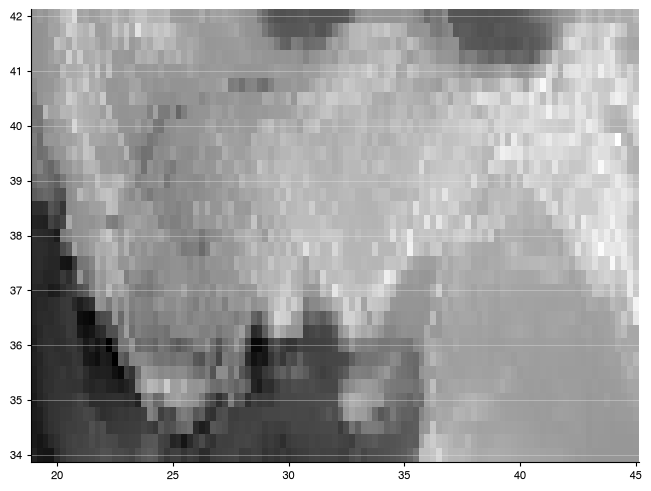

In [4]:
STEP = 0.25
# the pixels are cells centred on the samples, so the extent reaches half a step out
EXTENT = (
    RELIEF["lon"][0] - STEP / 2,
    RELIEF["lon"][-1] + STEP / 2,
    RELIEF["lat"][0] - STEP / 2,
    RELIEF["lat"][-1] + STEP / 2,
)

ImageChart(
    # the first row of an image is its top edge: north goes first
    data={"image": elevation[::-1], "extent": EXTENT},
).show()

## Customizing the Image Chart

Every customization is either a keyword argument of `ImageChart` or a `plot_image_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                        | See |
| :------------------------------------------ | :--------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                | [Title, axis labels and limits](#title-axis-labels-and-limits) |
| show part of the picture                    | `xmin`, `xmax`, `ymin`, `ymax`                             | [Title, axis labels and limits](#title-axis-labels-and-limits) |
| change the figure size or add a grid        | `figsize`, `show_grid`                                     | [Figure size and grid](#figure-size-and-grid) |
| color a 2-D array                           | `style={"plot_image_cmap": ...}`, `vmin`, `vmax`           | [Colormap and value range](#colormap-and-value-range) |
| draw a photo, a file or an RGB array        | `data={"image": path \| PIL image \| array}`             | [Pictures](#pictures) |
| smooth or keep the pixels                   | `style={"plot_image_interpolation": ...}`                  | [Interpolation](#interpolation) |
| fade the picture                            | `style={"plot_image_alpha": ...}`                          | [Transparency](#transparency) |
| keep the pixels square                      | `style={"plot_image_aspect": "equal"}`                     | [Aspect](#aspect) |
| put the picture under or over other charts  | `position`, `Panel`                                        | [Composing with Panel](#composing-with-panel) |
| draw several pictures                       | a list of `data`, `subplots`                               | [Multiple Image Charts](#multiple-image-charts) |
| save the chart as an image                  | `save_figure`                                              | [Saving figures](../../utility/saving/) |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `position` | [`DRAW_POSITION`](../../../references/constants/#datachart.constants.DRAW_POSITION) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |

The keys of the data dictionary are listed in [ImageDataAttrs](../../../references/charts/imagechart/#datachart.typings.ImageDataAttrs), the style attributes in [ImageStyleAttrs](../../../references/charts/imagechart/#datachart.typings.ImageStyleAttrs).

### Title, axis labels and limits

A picture in data coordinates carries units, and the axis labels say which: here, degrees of longitude and latitude. `title`, `xlabel` and `ylabel` add them. The extent sets the axis range, and `xmin`, `xmax`, `ymin` and `ymax` narrow it to part of the picture, which is how a report zooms into the region that matters without cropping the array. The chart below zooms into south-eastern Türkiye, where the year's two largest earthquakes struck.

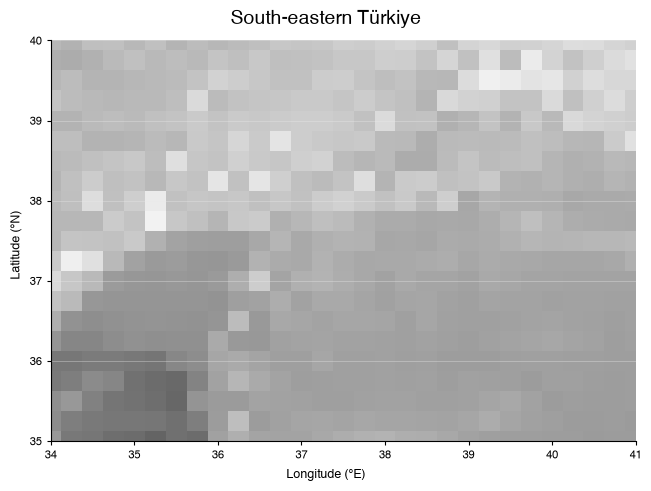

In [5]:
ImageChart(
    data={"image": elevation[::-1], "extent": EXTENT},
    title="South-eastern Türkiye",
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    # show only the corner of the relief around the mainshocks
    xmin=34,
    xmax=41,
    ymin=35,
    ymax=40,
).show()

### Figure size and grid

The region is three times as wide as it is tall, so the default, nearly square figure squeezes it. `figsize` takes a `(width, height)` tuple in inches or a preset from [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE). `show_grid` takes a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member; the grid draws over the picture, so it reads as a graticule of the map.

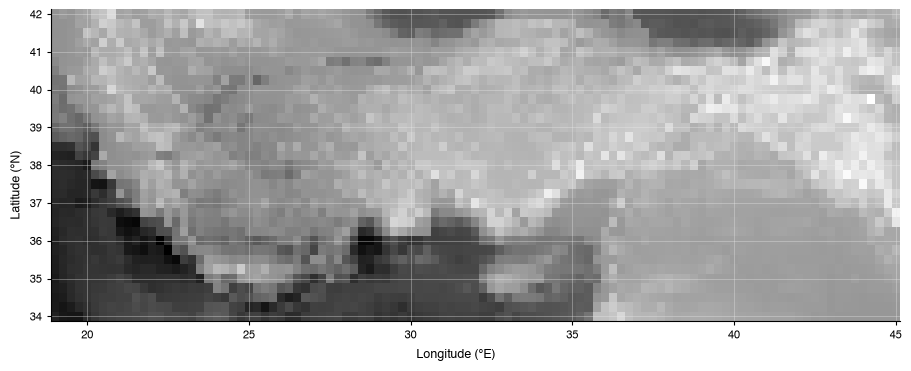

In [6]:
from datachart.constants import SHOW_GRID

ImageChart(
    data={"image": elevation[::-1], "extent": EXTENT},
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    # a wide figure for a wide region, and a graticule over the relief
    figsize=(9.0, 3.6),
    show_grid=SHOW_GRID.BOTH,
).show()

### Colormap and value range

A 2-D array has no colors of its own: each value is looked up in a colormap, grey by default so the picture stays behind the data. `plot_image_cmap` takes a [COLORS](../../../references/constants/#datachart.constants.COLORS) member, a matplotlib colormap name, or a list of colors (the [Colormaps](../../styling/colormaps/) guide shows them all). Elevation is signed, so a diverging colormap fits, and `vmin` and `vmax` set symmetrically about zero put sea level on its pale midpoint: the coastline appears without a coastline dataset. Without them the range comes from the data, and the midpoint lands wherever the data's middle happens to be.

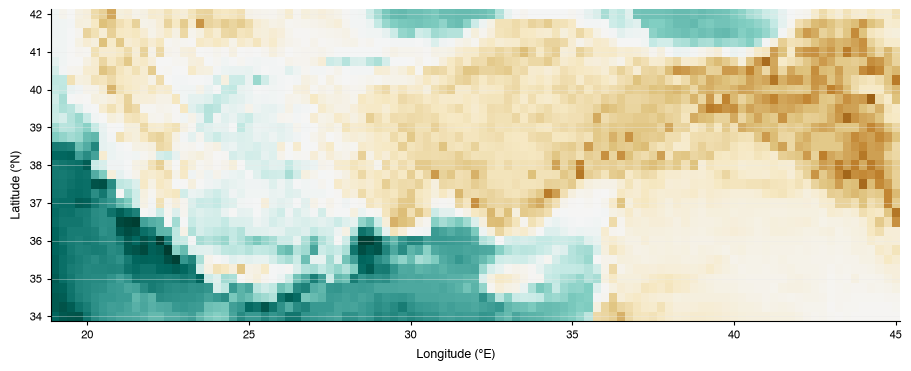

In [7]:
ImageChart(
    data={"image": elevation[::-1], "extent": EXTENT},
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    # a diverging colormap, with sea level on its midpoint
    style={"plot_image_cmap": "BrBG_r"},
    vmin=-4500,
    vmax=4500,
    figsize=(9.0, 3.6),
).show()

### Pictures

The picture does not have to be an array of values. `image` also takes an RGB or RGBA array of shape `(rows, columns, 3 or 4)`, which keeps its own colors, a PIL image, or the path of an image file, so a scanned map, a photograph or a floor plan goes in as it is. The cell below shades the relief into an RGB picture with matplotlib's `LightSource`, as a map renderer would, saves it as a PNG, and passes the path.

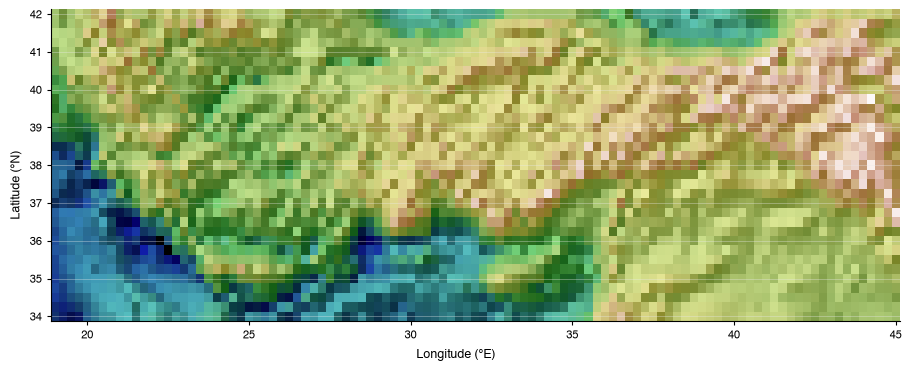

In [8]:
import os
import tempfile

import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# a hill-shaded relief, rendered to an RGB picture
shaded = LightSource(azdeg=315, altdeg=45).shade(
    elevation[::-1], cmap=plt.get_cmap("gist_earth"), vert_exag=0.02, blend_mode="soft"
)
path = os.path.join(tempfile.mkdtemp(), "relief.png")
plt.imsave(path, shaded)

ImageChart(
    # the path of the saved picture
    data={"image": path, "extent": EXTENT},
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    figsize=(9.0, 3.6),
).show()

### Interpolation

A quarter-degree grid is coarse: stretched over the axes, each value is a visible block. `plot_image_interpolation` decides how the pixels are resampled, using the names of matplotlib's `imshow`: `"nearest"` keeps every block sharp, which is honest about the resolution, while `"bilinear"` blends neighbouring values into a smooth surface, which reads better as a background. The default, `"antialiased"`, avoids moiré when a large picture is shrunk.

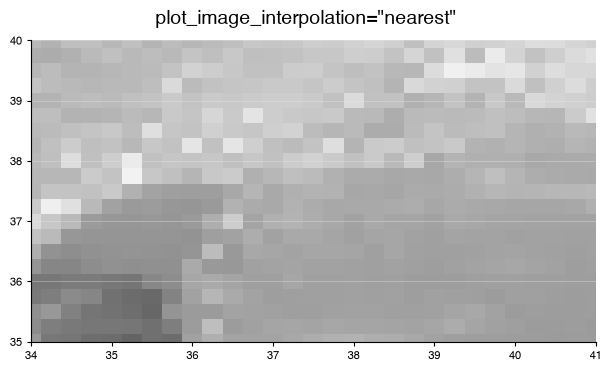

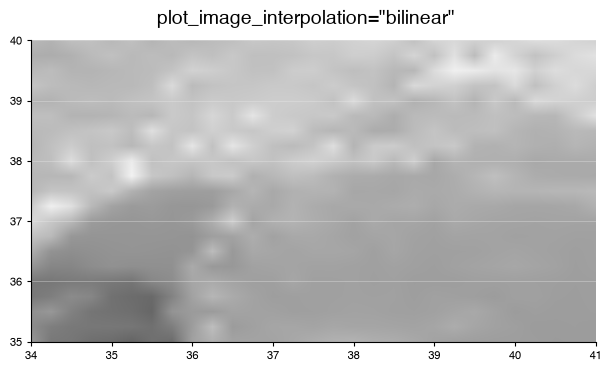

In [9]:
for interpolation in ["nearest", "bilinear"]:
    ImageChart(
        data={"image": elevation[::-1], "extent": EXTENT},
        title=f'plot_image_interpolation="{interpolation}"',
        # zoom in, so the pixels are large enough to see
        xmin=34,
        xmax=41,
        ymin=35,
        ymax=40,
        style={"plot_image_interpolation": interpolation},
        figsize=(6.0, 3.6),
    ).show()

### Transparency

A picture at full strength competes with the data drawn over it. `plot_image_alpha` fades it toward the axes background: below 1 the picture recedes and the marks win. The default is 1, because a faded picture is a choice about one figure, not a rule for every theme.

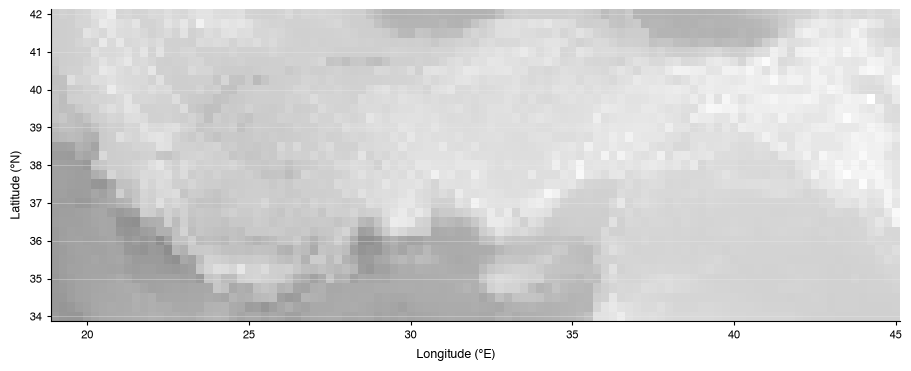

In [10]:
ImageChart(
    data={"image": elevation[::-1], "extent": EXTENT},
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    # a faded relief, to sit behind the data
    style={"plot_image_alpha": 0.45},
    figsize=(9.0, 3.6),
).show()

### Aspect

By default the picture stretches to fill its extent, and the axes keep the shape the figure gives them; that is what lets an image sit under any chart without reshaping it. `plot_image_aspect="equal"` keeps each pixel square instead, so one unit on x is as long as one unit on y, and the axes shrink to fit. For a floor plan in metres or a microscope image in micrometres that is the correct shape; for degrees of longitude and latitude it is only approximately right.

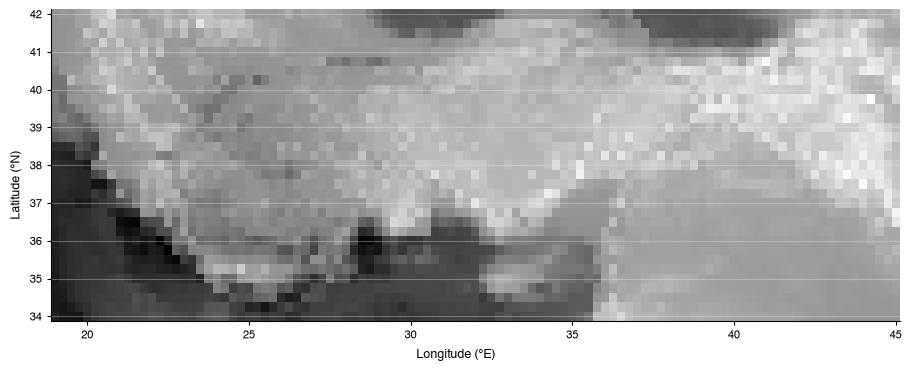

In [11]:
ImageChart(
    data={"image": elevation[::-1], "extent": EXTENT},
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    # square pixels: a degree is as long on both axes
    style={"plot_image_aspect": "equal"},
    figsize=(9.0, 3.6),
).show()

## Composing with Panel

An image chart is made to sit under another chart. [Panel](../../utility/panel/) overlays figures in one coordinate space, and the image and the data meet there because they share the same units. The picture carries no series: it takes no color from the palette, adds no legend entry, and ignores emphasis, so the chart over it looks as it would alone. The extent counts toward the axis range like any other chart's data, so the axes cover both the picture and the marks.

`position` decides where the picture sits in the drawing order, with an [DRAW_POSITION](../../../references/constants/#datachart.constants.DRAW_POSITION) member. The default, `DRAW_POSITION.BELOW`, puts it under the grid and every mark, whatever the order of the figures in `Panel`: below, the scatter chart comes first and still draws on top.

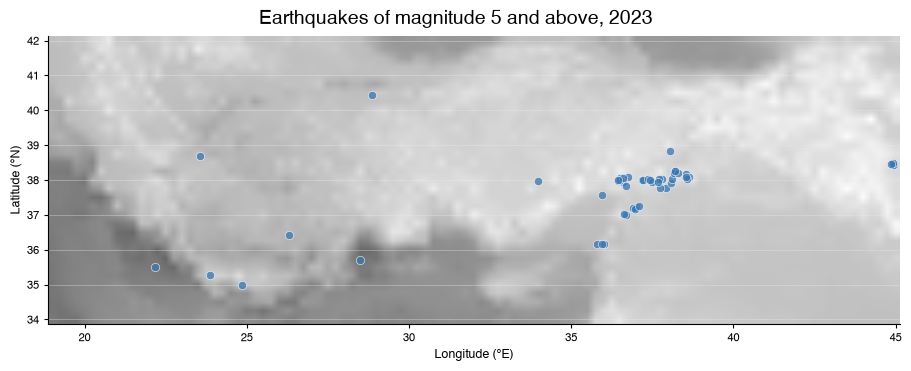

In [12]:
from datachart.constants import DRAW_POSITION

relief = ImageChart(
    data={"image": elevation[::-1], "extent": EXTENT},
    style={"plot_image_alpha": 0.6, "plot_image_interpolation": "bilinear"},
)
quakes = ScatterChart(
    [{"x": lon, "y": lat} for _, lat, lon, _, _ in QUAKES],
)

Panel(
    # the order does not matter: the image sits below by its position
    [quakes, relief],
    title="Earthquakes of magnitude 5 and above, 2023",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    figsize=(9.0, 3.6),
).show()

`DRAW_POSITION.ABOVE` draws the picture over the marks instead, and still under reference lines and text notes. Its use is a picture that is meant to cover: a watermark, or a mask. The mask below is an RGBA array, transparent over the study area around the 2023 mainshocks and a translucent grey everywhere else, so the rest of the region recedes without disappearing.

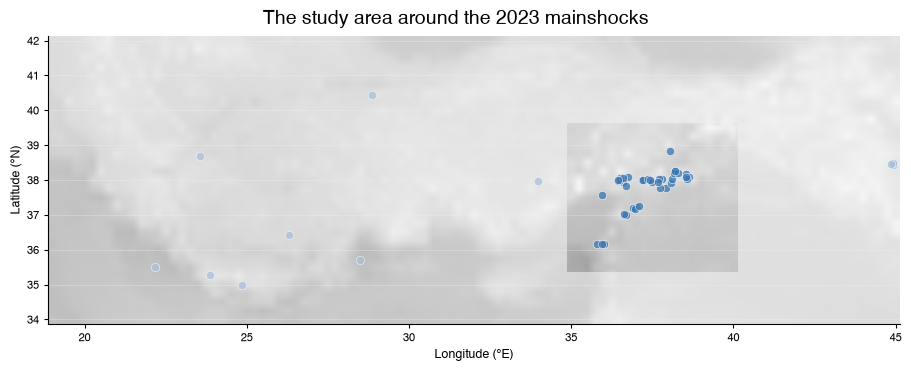

In [13]:
# transparent inside the study area, a translucent grey outside it
mask = np.zeros((*elevation.shape, 4))
mask[..., :3] = 0.95
mask[..., 3] = 0.6
lat = np.array(RELIEF["lat"])[::-1]
lon = np.array(RELIEF["lon"])
inside = ((lat >= 35.5) & (lat <= 39.5))[:, None] & ((lon >= 35) & (lon <= 40))[None, :]
mask[inside, 3] = 0

Panel(
    [
        relief,
        quakes,
        ImageChart({"image": mask, "extent": EXTENT}, position=DRAW_POSITION.ABOVE),
    ],
    title="The study area around the 2023 mainshocks",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    figsize=(9.0, 3.6),
).show()

## Multiple Image Charts

A list of dictionaries in `data` draws several pictures: overlaid on one axes by default, each placed by its own extent, or one per subplot with `subplots=True`. `subtitle` names each one, `max_cols` limits the subplots per row, and `sharex` and `sharey` put them on one axis range. `vmin` and `vmax` apply to every 2-D array, which keeps their colors comparable. Below, the land and the sea floor are split into two arrays and drawn side by side, each with the colormap that suits it.

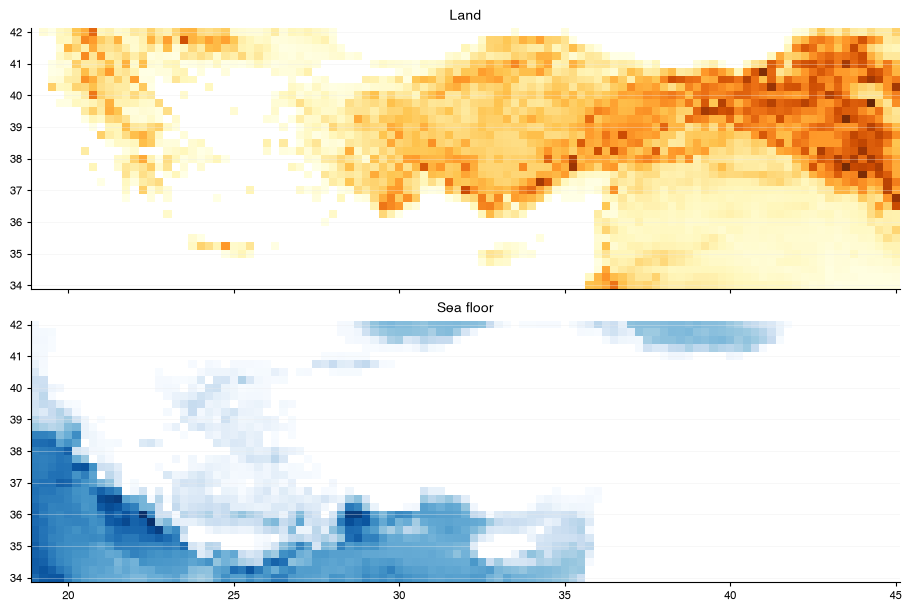

In [14]:
land = np.where(elevation >= 0, elevation, np.nan)
sea = np.where(elevation < 0, elevation, np.nan)

ImageChart(
    data=[
        {"image": land[::-1], "extent": EXTENT},
        {"image": sea[::-1], "extent": EXTENT},
    ],
    subtitle=["Land", "Sea floor"],
    style=[{"plot_image_cmap": "YlOrBr"}, {"plot_image_cmap": "Blues_r"}],
    subplots=True,
    max_cols=1,
    sharex=True,
    figsize=(9.0, 6.0),
).show()

The empty cells of each array are `NaN`, which a colormap leaves transparent: the axes background shows through where the other half of the region is.

## Real-World Examples

### Where did the strongest earthquakes of 2023 strike? (relief under a bubble scatter, notes)

The first question of an earthquake report is where, and a map answers it better than bare coordinates. A faded, smoothed relief goes under a scatter chart whose bubble size is the magnitude, so the reader sees at once that the largest events sit on the mountain front of south-eastern Türkiye, and that the smaller ones trace the Hellenic arc south of Crete. A note names the Kahramanmaraş sequence.

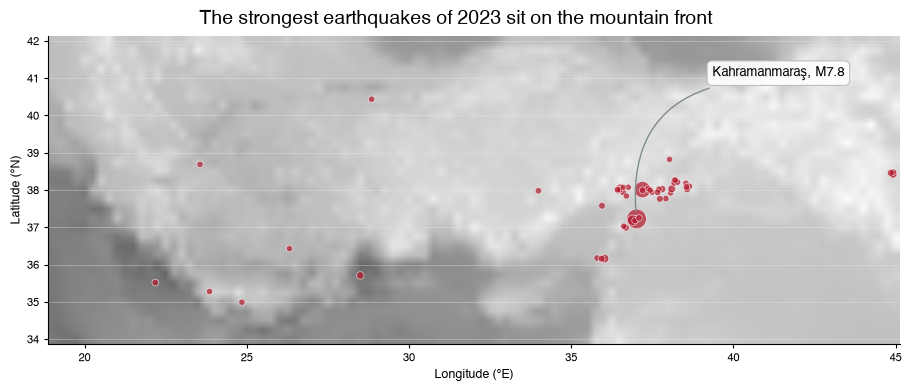

In [15]:
main = max(QUAKES, key=lambda quake: quake[4])

bubbles = ScatterChart(
    # the bubble area grows with the energy of the earthquake
    [
        {"x": lon, "y": lat, "size": 4 ** (magnitude - 4.3)}
        for _, lat, lon, _, magnitude in QUAKES
    ],
    style={"plot_scatter_color": "#b2182b", "plot_scatter_alpha": 0.7},
    texts={
        "text": f"Kahramanmaraş, M{main[4]:.1f}",
        # the note sits in the axes corner, so it stays put when the view narrows
        "x": 0.78,
        "y": 0.88,
        "coords": "axes",
        "target": (main[2], main[1]),
    },
)

Panel(
    [relief, bubbles],
    title="The strongest earthquakes of 2023 sit on the mountain front",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    figsize=(9.0, 3.8),
).show()

### Which desks run warm? (a floor plan under sensor readings, equal aspect)

A building report places its readings on the floor plan, because a temperature means little until the reader knows which room it came from. The floor plan here is illustrative, drawn as an RGB array in the hidden cell below, and so are the twelve sensor readings. The plan is 20 by 12 metres, so the extent is in metres and `plot_image_aspect="equal"` keeps the rooms their true shape; the scatter chart colors each sensor by its temperature band.

In [16]:
# an illustrative 20 m x 12 m office: walls in dark grey on a light floor
PLAN = np.full((120, 200, 3), 0.96)
walls = [
    (slice(0, 3), slice(0, 200)), (slice(117, 120), slice(0, 200)),
    (slice(0, 120), slice(0, 3)), (slice(0, 120), slice(197, 200)),
    (slice(0, 120), slice(78, 81)), (slice(0, 120), slice(138, 141)),
    (slice(58, 61), slice(0, 60)), (slice(58, 61), slice(96, 138)),
    (slice(58, 61), slice(141, 200)),
]
for rows, cols in walls:
    PLAN[rows, cols] = 0.3

# (x in m, y in m, temperature in °C) per sensor
SENSORS = [
    (3.0, 3.0, 22.1), (6.0, 9.5, 22.4), (4.0, 6.5, 21.9),
    (10.5, 2.5, 23.8), (11.0, 9.0, 24.6), (9.0, 6.0, 24.1),
    (15.5, 3.0, 26.9), (16.5, 9.5, 27.4), (18.5, 6.5, 26.2),
    (12.5, 5.0, 24.0), (1.5, 10.5, 21.6), (18.0, 1.5, 25.8),
]

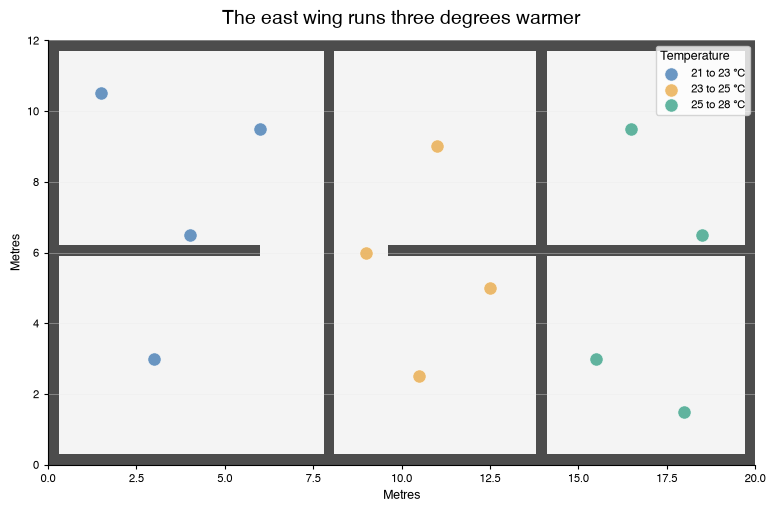

In [17]:
def band(temperature):
    if temperature < 23:
        return "21 to 23 °C"
    return "23 to 25 °C" if temperature < 25 else "25 to 28 °C"


Panel(
    [
        ImageChart(
            {"image": PLAN, "extent": (0, 20, 0, 12)},
            # metres on both axes: keep the rooms their true shape
            style={"plot_image_aspect": "equal"},
        ),
        ScatterChart(
            [{"x": x, "y": y, "hue": band(t)} for x, y, t in SENSORS],
            style={"plot_scatter_size": 90},
        ),
    ],
    title="The east wing runs three degrees warmer",
    xlabel="Metres",
    ylabel_left="Metres",
    show_legend=True,
    legend={"title": "Temperature"},
    figsize=(8.0, 5.0),
).show()

### How does the aftershock zone compare with the region? (limits, Grid)

A report often pairs the overview with a close-up. The same composed panel, drawn twice with different limits, gives both; [Grid](../../utility/grid/) arranges them side by side. The limits narrow the axes to the zone around the mainshocks, and the relief and the bubbles follow, because both are drawn in the same coordinates.

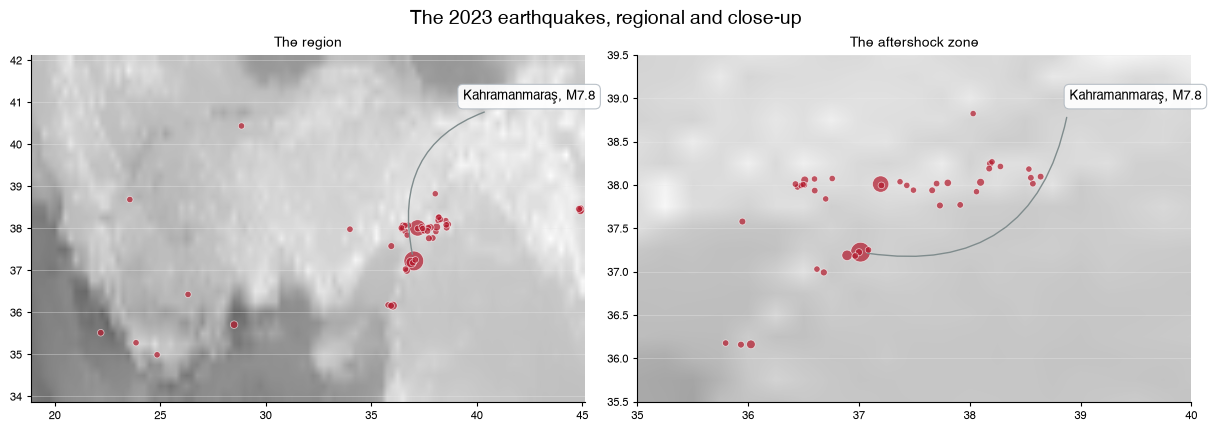

In [18]:
from datachart.utils import Grid

overview = Panel([relief, bubbles], title="The region", figsize=(9.0, 3.8))
closeup = Panel(
    [relief, bubbles],
    title="The aftershock zone",
    # narrow the axes to the mainshocks; the picture follows
    xmin=35,
    xmax=40,
    ymin=35.5,
    ymax=39.5,
)

Grid(
    [[overview, closeup]],
    title="The 2023 earthquakes, regional and close-up",
    figsize=(12.0, 4.2),
).show()